# 이상지질혈증 예측 - XGBoost Optuna 하이퍼파라미터 튜닝

- 타겟: `이상지질혈증유병` (0: 없음 / 1: 있음)
- 모델: XGBoost + Optuna TPE Sampler
- 데이터: x1_preprocessed.csv
- Threshold: **0.45 고정** (Recall ≥ 0.80 조건 하 최적)
- 목표: **Recall ≥ 0.80 유지하면서 F1 최대화**
- 검증: Stratified 5-Fold CV

In [ ]:
import os
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import xgboost as xgb
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold

optuna.logging.set_verbosity(optuna.logging.WARNING)


warnings.filterwarnings("ignore")
matplotlib.rcParams["font.family"] = "DejaVu Sans"


# ── 경로 설정 ──────────────────────────────────────────────
INPUT_PATH = "/Users/Jiyeon/Desktop/final_project/ML/data/x1_preprocessed.csv"
NPY_DIR = "/Users/Jiyeon/Desktop/final_project/ML/outputs/oof"
RANDOM_STATE = 42
THRESHOLD = 0.45
N_TRIALS = 50

## 1. 데이터 로드

In [2]:
df = pd.read_csv(INPUT_PATH)
print(f"로드 완료 | shape: {df.shape}")

로드 완료 | shape: (6033, 32)


## 2. 피처 / 타겟 분리

In [3]:
TARGET = "이상지질혈증유병"
DROP_COLS = ["고혈압유병", "당뇨유병", "이상지질혈증유병", "비만단계"]

data = df.dropna(subset=[TARGET]).copy()
X = data.drop(columns=DROP_COLS)
y = data[TARGET].astype(int)

neg, pos = (y == 0).sum(), (y == 1).sum()
ratio = neg / pos
print(f"샘플 수: {len(y)}  |  정상: {neg}  |  이상지질혈증: {pos}")
print(f"불균형 비율: {ratio:.4f}  |  scale_pos_weight: {ratio:.4f}")

샘플 수: 6033  |  정상: 4475  |  이상지질혈증: 1558
불균형 비율: 2.8723  |  scale_pos_weight: 2.8723


## 3. Optuna Objective 정의

In [4]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 3.0),
        "scale_pos_weight": ratio,
        "eval_metric": "auc",
        "early_stopping_rounds": 50,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": 0,
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        m = xgb.XGBClassifier(**params)
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        proba = m.predict_proba(X_val)[:, 1]
        pred = (proba >= THRESHOLD).astype(int)
        recall = recall_score(y_val, pred)
        penalty = max(0, 0.8 - recall) * 2
        scores.append(f1_score(y_val, pred) - penalty)
    return np.mean(scores)

## 4. Optuna 최적화 실행

In [5]:
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n최적 trial: {study.best_trial.number}")
print(f"최적 score: {study.best_value:.4f}")
print("\n[최적 파라미터]")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 35. Best value: 0.569824: 100%|██████████| 50/50 [01:12<00:00,  1.45s/it]


최적 trial: 35
최적 score: 0.5698

[최적 파라미터]
  n_estimators: 724
  learning_rate: 0.08523962460966993
  max_depth: 3
  min_child_weight: 2
  subsample: 0.6988848758039171
  colsample_bytree: 0.6553589313598337
  gamma: 0.4917080422113815
  reg_alpha: 0.4493174642562978
  reg_lambda: 2.5831774286423133


## 5. Optuna 최적화 과정 시각화

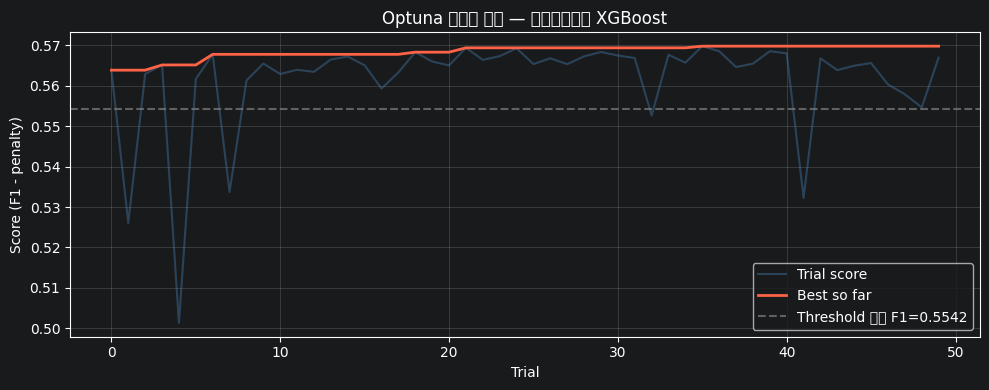

In [6]:
trial_values = [t.value for t in study.trials]
best_so_far = np.maximum.accumulate(trial_values)

plt.figure(figsize=(10, 4))
plt.plot(trial_values, alpha=0.4, color="steelblue", label="Trial score")
plt.plot(best_so_far, color="tomato", lw=2, label="Best so far")
plt.axhline(y=0.5542, color="gray", linestyle="--", alpha=0.7, label="Threshold 조정 F1=0.5542")
plt.xlabel("Trial")
plt.ylabel("Score (F1 - penalty)")
plt.title("Optuna 최적화 과정 — 이상지질혈증 XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 최적 파라미터로 최종 학습 & 평가

In [7]:
best_params = study.best_params.copy()
best_params.update(
    {
        "scale_pos_weight": ratio,
        "eval_metric": "auc",
        "early_stopping_rounds": 50,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": 0,
    }
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = np.zeros(len(y))
fold_scores = []

print("=" * 65)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    model = xgb.XGBClassifier(**best_params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    proba = model.predict_proba(X_val)[:, 1]
    oof_proba[val_idx] = proba
    pred = (proba >= THRESHOLD).astype(int)
    cm_f = confusion_matrix(y_val, pred)
    fold_scores.append(
        {
            "fold": fold,
            "auc": roc_auc_score(y_val, proba),
            "f1": f1_score(y_val, pred),
            "recall": recall_score(y_val, pred),
            "precision": precision_score(y_val, pred),
            "fp": int(cm_f[0, 1]),
            "best_iter": model.best_iteration,
        }
    )
    print(
        f"  Fold {fold} | AUC: {fold_scores[-1]['auc']:.4f} | "
        f"Recall: {fold_scores[-1]['recall']:.4f} | "
        f"F1: {fold_scores[-1]['f1']:.4f} | "
        f"best_iter: {model.best_iteration}"
    )

scores_df = pd.DataFrame(fold_scores)
print("=" * 65)
print(
    f"  평균   | AUC: {scores_df.auc.mean():.4f}±{scores_df.auc.std():.4f} "
    f"| Recall: {scores_df.recall.mean():.4f}±{scores_df.recall.std():.4f} "
    f"| F1: {scores_df.f1.mean():.4f}±{scores_df.f1.std():.4f}"
)

  Fold 1 | AUC: 0.8042 | Recall: 0.8590 | F1: 0.5566 | best_iter: 56
  Fold 2 | AUC: 0.7922 | Recall: 0.8878 | F1: 0.5723 | best_iter: 42
  Fold 3 | AUC: 0.8026 | Recall: 0.8910 | F1: 0.5768 | best_iter: 83
  Fold 4 | AUC: 0.8246 | Recall: 0.8875 | F1: 0.5756 | best_iter: 70
  Fold 5 | AUC: 0.7948 | Recall: 0.8746 | F1: 0.5678 | best_iter: 41
  평균   | AUC: 0.8037±0.0128 | Recall: 0.8800±0.0133 | F1: 0.5698±0.0082


## OOF proba 저장 (.npy)

In [8]:
os.makedirs(NPY_DIR, exist_ok=True)
npy_path = os.path.join(NPY_DIR, "oof_proba_HL_xgboost_optuna.npy")
oof_array = np.stack([oof_proba, y.values], axis=1)  # col0: proba, col1: y_true
np.save(npy_path, oof_array)
print(f"저장 완료 → {npy_path}")
print(f"shape: {oof_array.shape}  (col0: oof_proba, col1: y_true)")
loaded = np.load(npy_path)
print(f"로드 확인: shape={loaded.shape}, 일치={np.allclose(oof_array, loaded)}")

저장 완료 → /Users/Jiyeon/Desktop/final_project/ML/outputs/oof/oof_proba_HL_xgboost_optuna.npy
shape: (6033, 2)  (col0: oof_proba, col1: y_true)
로드 확인: shape=(6033, 2), 일치=True


## 7. OOF 전체 성능 & 비교

In [9]:
pred_oof = (oof_proba >= THRESHOLD).astype(int)
cm = confusion_matrix(y, pred_oof)

oof_auc = roc_auc_score(y, oof_proba)
oof_rec = recall_score(y, pred_oof)
oof_prec = precision_score(y, pred_oof)
oof_f1 = f1_score(y, pred_oof)
oof_acc = float((pred_oof == y).mean())

# threshold 조정 단계 수치
BASE = {"auc": 0.7879, "recall": 0.8427, "precision": 0.4129, "f1": 0.5542, "acc": 0.6499, "fp": 1867, "fn": 245}

print("=" * 55)
print(f"  {'지표':<12}  {'Threshold 조정':>14}  {'Optuna':>10}  변화")
print("=" * 55)
for label, base_v, opt_v in [
    ("AUC-ROC", BASE["auc"], oof_auc),
    ("Recall", BASE["recall"], oof_rec),
    ("Precision", BASE["precision"], oof_prec),
    ("F1-score", BASE["f1"], oof_f1),
    ("Accuracy", BASE["acc"], oof_acc),
]:
    d = opt_v - base_v
    arrow = "▲" if d > 0 else ("▼" if d < 0 else "─")
    print(f"  {label:<12}  {base_v:>14.4f}  {opt_v:>10.4f}  {arrow} {abs(d):.4f}")
print(
    f"  {'FP':<12}  {BASE['fp']:>14}  {cm[0, 1]:>10}  {'▼' if cm[0, 1] < BASE['fp'] else '▲'} {abs(cm[0, 1] - BASE['fp'])}"
)
print(
    f"  {'FN':<12}  {BASE['fn']:>14}  {cm[1, 0]:>10}  {'▼' if cm[1, 0] < BASE['fn'] else '▲'} {abs(cm[1, 0] - BASE['fn'])}"
)
print("=" * 55)

print(f"\n[분류 리포트 — Optuna (threshold={THRESHOLD})]")
print(classification_report(y, pred_oof, target_names=["정상(0)", "이상지질혈증(1)"]))

  지표              Threshold 조정      Optuna  변화
  AUC-ROC               0.7879      0.8033  ▲ 0.0154
  Recall                0.8427      0.8800  ▲ 0.0373
  Precision             0.4129      0.4213  ▲ 0.0084
  F1-score              0.5542      0.5698  ▲ 0.0156
  Accuracy              0.6499      0.6569  ▲ 0.0070
  FP                      1867        1883  ▲ 16
  FN                       245         187  ▼ 58

[분류 리포트 — Optuna (threshold=0.45)]
              precision    recall  f1-score   support

       정상(0)       0.93      0.58      0.71      4475
   이상지질혈증(1)       0.42      0.88      0.57      1558

    accuracy                           0.66      6033
   macro avg       0.68      0.73      0.64      6033
weighted avg       0.80      0.66      0.68      6033



## 8. Confusion Matrix 비교

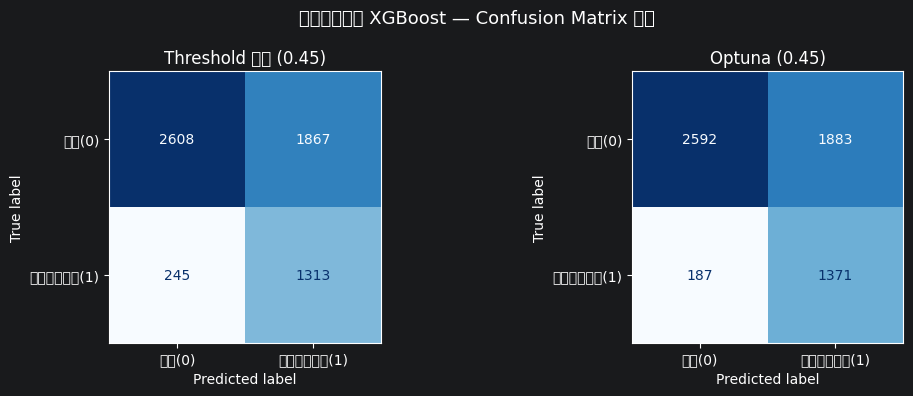

In [10]:
cm_prev = np.array([[2608, 1867], [245, 1313]])  # threshold 조정 단계

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm_data, title in zip(axes, [cm_prev, cm], ["Threshold 조정 (0.45)", "Optuna (0.45)"]):
    ConfusionMatrixDisplay(cm_data, display_labels=["정상(0)", "이상지질혈증(1)"]).plot(
        cmap="Blues", ax=ax, colorbar=False
    )
    ax.set_title(title)
plt.suptitle("이상지질혈증 XGBoost — Confusion Matrix 비교", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Feature Importance (gain, 마지막 fold)

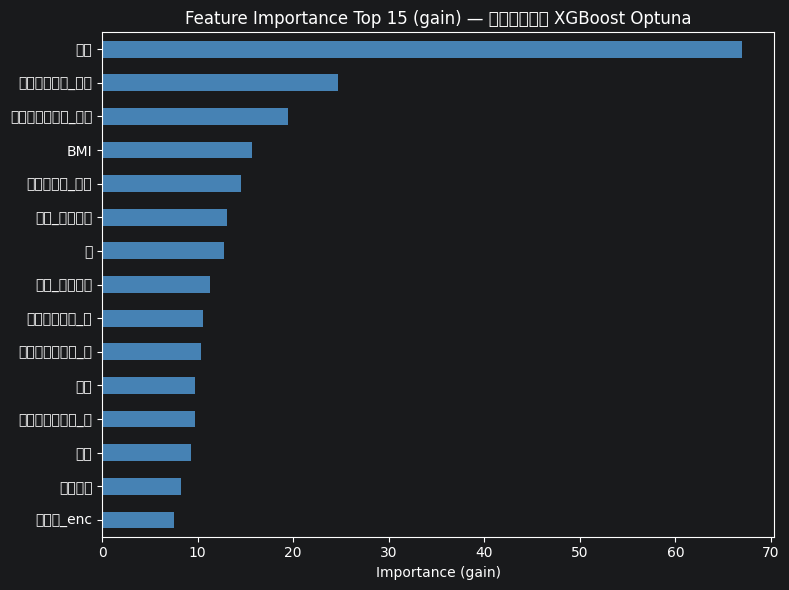

   1. 나이: 67.0
   2. 고혈압가족력_형제: 24.7
   3. 고지혈증가족력_형제: 19.4
   4. BMI: 15.7
   5. 당뇨가족력_형제: 14.5
   6. 직업_주부학생: 13.1
   7. 키: 12.8
   8. 직업_관리전문: 11.3
   9. 고혈압가족력_모: 10.6
  10. 고지혈증가족력_모: 10.3
  11. 체중: 9.7
  12. 고지혈증가족력_부: 9.7
  13. 성별: 9.3
  14. 현재흡연: 8.2
  15. 음주량_enc: 7.5


In [11]:
booster = model.get_booster()
gain = pd.Series(booster.get_score(importance_type="gain"))
gain = gain.reindex(X.columns, fill_value=0).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
gain.head(15)[::-1].plot(kind="barh", color="steelblue")
plt.title("Feature Importance Top 15 (gain) — 이상지질혈증 XGBoost Optuna")
plt.xlabel("Importance (gain)")
plt.tight_layout()
plt.show()

for i, (feat, imp) in enumerate(gain.head(15).items(), 1):
    print(f"  {i:2d}. {feat}: {imp:.1f}")

## 10. DB 로그 저장

In [12]:
import sys

sys.path.insert(0, "/Users/Jiyeon/Desktop/final_project/ML")
from model_logger import ModelLogger

logger = ModelLogger("/Users/Jiyeon/Desktop/final_project/ML/model_result.db")

run_id = logger.log_run(
    target_var="이상지질혈증",
    model_name="XGBoost",
    stage="optuna",
    hyperparams={
        "learning_rate": best_params["learning_rate"],
        "max_depth": best_params["max_depth"],
        "n_estimators": best_params["n_estimators"],
        "class_weight": {0: 1.0, 1: round(ratio, 4)},
        "min_child_weight": best_params["min_child_weight"],
        "subsample": best_params["subsample"],
        "colsample_bytree": best_params["colsample_bytree"],
        "gamma": best_params["gamma"],
        "reg_alpha": best_params["reg_alpha"],
        "reg_lambda": best_params["reg_lambda"],
    },
    data_info={
        "feature_count": X.shape[1],
        "train_test_split": "5-Fold CV",
        "scaling_method": "None",
    },
    oof_metrics={
        "accuracy": oof_acc,
        "recall": oof_rec,
        "precision": oof_prec,
        "f1_score": oof_f1,
        "auc_roc": oof_auc,
        "cm": cm.tolist(),
    },
    fold_scores=scores_df.to_dict("records"),
    top_features=gain.head(15).to_dict(),
    note=f"Optuna {N_TRIALS} trials. 목표: Recall>=0.80 유지하며 F1 최대화. threshold={THRESHOLD} 고정.",
)

print(f"저장 완료 → run_id: {run_id}")
print()
print("[전체 실험 목록]")
print(logger.compare_runs().to_string(index=False))

[ModelLogger] 저장 완료 | run_id=9 | 이상지질혈증 XGBoost (optuna)
저장 완료 → run_id: 9

[전체 실험 목록]
 run_id          created_at target_var model_name          stage  auc_roc   recall  precision  f1_score  accuracy
      9 2026-05-15 19:00:15     이상지질혈증    XGBoost         optuna 0.803302 0.879974   0.421328  0.569825  0.656887
      8 2026-05-15 18:06:03     이상지질혈증    XGBoost threshold_0.45 0.787916 0.842747   0.412893  0.554242  0.649925
      7 2026-05-15 17:34:49         당뇨    XGBoost    optuna_shap 0.790561 0.839704   0.246829  0.381513  0.634013
      6 2026-05-15 17:24:13         당뇨    XGBoost         optuna 0.804071 0.831073   0.266403  0.403472  0.669650
      5 2026-05-15 17:02:27         당뇨    XGBoost threshold_0.45 0.783068 0.816276   0.253446  0.386795  0.652080
      4 2026-05-15 16:25:48        고혈압    XGBoost    optuna_shap 0.859112 0.826190   0.542399  0.654871  0.757500
      3 2026-05-15 16:22:42        고혈압    XGBoost    optuna_shap 0.859112 0.826190   0.542399  0.654871  0.757500
 